# Imports

In [11]:
%load_ext autoreload
%autoreload 2

import logging
import numpy as np

import msml610_utils as ut

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


INFO:msml610_utils:Setting notebook style
INFO:msml610_utils:Notebook signature
INFO:msml610_utils:numpy version=1.26.4
INFO:msml610_utils:pymc version=5.18.2
INFO:msml610_utils:matplotlib version=3.10.3
INFO:msml610_utils:arviz version=0.21.0
INFO:msml610_utils:preliz version=0.19.0


Python 3.12.3
Linux 7d77d2247121 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


In [5]:
import helpers.hio as hio
import L09_05_03_multivariate_kalman_filter_utils as time_ut

dst_dir = "figures"
hio.create_dir(dst_dir, incremental=True)
# cp msml610/tutorials/figures/*.png msml610/lectures_source/figures

In [16]:
!sudo /bin/bash -c "(source /venv/bin/activate; pip install --quiet filterpy)"

# Cell 1: Multi-variate Gaussians

- A multivariate Gaussian is a normal distribution on multiple dimensions
    - The dimensions don't need to be necessarily spatial dimensions
    - E.g., position, velocity, acceleration in 3 dimensions
    - E.g., milk production and feed rate at a dairy

- The components of a Gaussian are correlated
  - E.g., height and weight of people are (positively) correlated
  - E.g., outdoor temperature and home heating bills are (negatively) correlated
  - E.g., the weight of my dog and the price of coffee are uncorrelated

- Correlation allows prediction
  - E.g., height and weight are correlated. If you are much taller than me, I can predict that you weigh more than me
  - Noise in the measurements, uncertainty in the knowledge of the system, intrinsic stochasticity make correlations (and predictions) imperfect

- Assuming linear correlation, the covariance between two vars is defined as
  $$cov(X, Y) = E[(X - \mu_X)(Y - \mu_Y)]$$

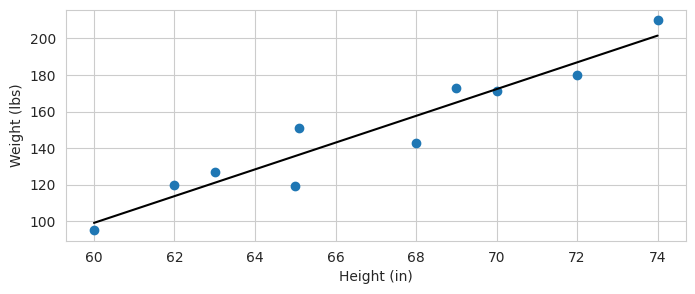

cov=
 [[  20.58322222  150.77888889]
 [ 150.77888889 1213.65555556]]


In [14]:
height = [60, 62, 63, 65, 65.1, 68, 69, 70, 72, 74]
weight = [95, 120, 127, 119, 151, 143, 173, 171, 180, 210]
time_ut.plot_correlated_data(height, weight, xlabel='Height (in)', ylabel='Weight (lbs)', equal=False)
print("cov=\n", np.cov(height, weight))

In [18]:
from filterpy.stats import gaussian, multivariate_gaussian

x = [2.5, 7.3]
mu = [2.0, 7.0]
P = [[8., 0.], 
     [0., 3.]]

multivariate_gaussian(x, mu, P)

0.031507521572225645

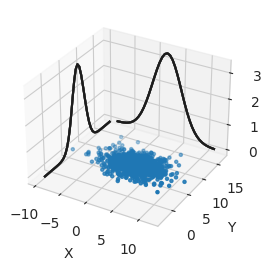

In [19]:
time_ut.plot_3d_sampled_covariance(mu, P)

# Cell 1: Sum and Product of Gaussians

In [3]:
x = time_ut.Gaussian(3.4, 10.1)
print(x)
print("x.mean=", x.mean)
print("x.var=", x.var)

N(mu=3.400, sigma^2=10.100)
x.mean= 3.4
x.var= 10.1


## Cell 1.1: Sum of Gaussians
- Given two Gaussians $X$ and $Y$
  $$X \sim Normal(\mu_1, \sigma_1^2)$$
  $$Y \sim Normal(\mu_2, \sigma_2^2)$$
- For correlated Gaussians with correlation coefficient $\rho$, the sum
  $Z = X + Y$ is a Gaussian $Normal(\mu, \sigma^2)$ with:
  $$\mu = \mu_1 + \mu_2$$
  $$\sigma^2 = \sigma_1^2 + \sigma_2^2 + 2\rho\sigma_1\sigma_2$$
- **Interpretation:**
  - The mean is the sum of the means (by linearity)
  - For independent Gaussians ($\rho = 0$), the variance is the sum of
    variances (uncertainty increases)
  - Positive correlation increases variance, negative correlation decreases it

In [4]:
# Sum two Gaussians.
x = time_ut.Gaussian(10, 0.2**2)
y = time_ut.Gaussian(15, 0.7**2)

z = time_ut.gaussian_sum(x, y)
print(z)

N(mu=25.000, sigma^2=0.530)


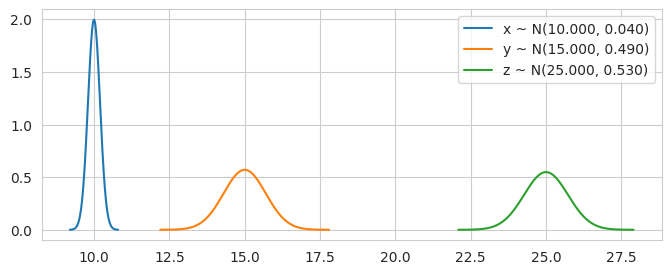

In [5]:
ax = time_ut.plot_gaussian(x, label="x")
time_ut.plot_gaussian(y, ax=ax, label="y")
time_ut.plot_gaussian(z, ax=ax, label="z");

**Goal**:
- Explore the sum of two Gaussians $X \sim N(\mu_1, \sigma_1^2)$ and
  $Y \sim N(\mu_2, \sigma_2^2)$ with correlation $\rho$
- Observe how mean and variance of $Z = X + Y$ change with parameters

**Plots**:
- Input Gaussians $X$ (blue) and $Y$ (yellow) as filled PDFs
- Analytical sum $Z$ (red line)
- Numerical sum via sampling (light coral histogram)

**Parameters**:
- `mu1` ($\mu_1$): mean of $X$
- `sigma1` ($\sigma_1$): standard deviation of $X$
- `mu2` ($\mu_2$): mean of $Y$
- `sigma2` ($\sigma_2$): standard deviation of $Y$
- `rho` ($\rho$): correlation coefficient between $X$ and $Y$

**Key observations**:
- The mean of $Z$ is always $\mu_1 + \mu_2$ regardless of correlation
- Positive $\rho$ increases variance; negative $\rho$ decreases it
- For independent Gaussians ($\rho = 0$), variance is simply
  $\sigma_1^2 + \sigma_2^2$

In [6]:
# Interactive exploration of sum of Gaussians with correlation.
time_ut.cell1_1_plot_gaussian_sum()

## Cell 1.2: Product of Gaussians
- Given two Gaussians $X$ and $Y$
  $$X \sim Normal(\mu_X, \sigma_X^2)$$
  $$Y \sim Normal(\mu_Y, \sigma_Y^2)$$
- The product $Z = X \cdot Y$ (PDF multiplication) is a Gaussian
  $Normal(\mu_Z, \sigma_Z^2)$ with:
  $$\mu_Z = \frac{\mu_X \sigma_Y^2 + \mu_Y \sigma_X^2}{\sigma_X^2 + \sigma_Y^2}$$
  $$\sigma_Z^2 = \frac{\sigma_X^2 \sigma_Y^2}{\sigma_X^2 + \sigma_Y^2}$$
- **Interpretation:**
  - Reduces variance by incorporating more information
  - If one Gaussian $X$ is narrower (more accurate), result leans towards $X$
  - If two Gaussians are similar (measures corroborate), result becomes more
    certain

**Gaussian products in terms of precision**

- The precision of a Gaussian is
  $$\tau = \frac{1}{\sigma^2}$$
- The precision of the product is the sum of the precisions
  $$\tau_Z = \tau_X + \tau_Y$$
  $$\sigma_Z^2 = \frac{1}{\frac{1}{\sigma_X^2} + \frac{1}{\sigma_Y^2}}$$
- The mean is the average of the means weighted by the precisions
  $$\mu_Z = \sigma_Z^2 (\frac{\mu_X}{\sigma_X^2} + \frac{\mu_Y}{\sigma_Y^2})$$

- The mean is averaged towards the more certain Gaussian
- The variance is smaller than both

In [7]:
# Product of two equal Gaussians.
x = time_ut.Gaussian(10, 1.0)

z = time_ut.gaussian_multiply(x, x)
print(z)

# The result is more certain than both.

N(mu=10.000, sigma^2=0.500)


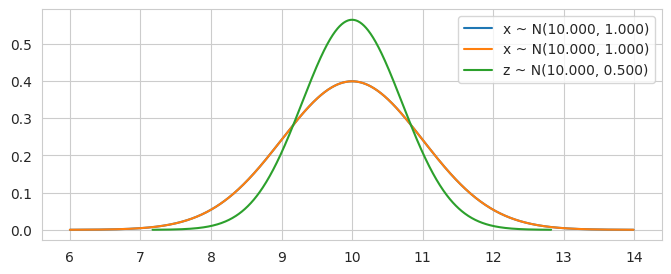

In [8]:
ax = time_ut.plot_gaussian(x, label="x")
time_ut.plot_gaussian(x, ax=ax, label="x")
time_ut.plot_gaussian(z, ax=ax, label="z");

N(mu=10.377, sigma^2=0.037)


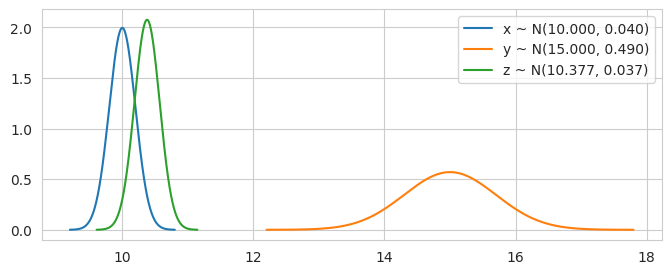

In [9]:
# Product of two different Gaussians.
x = time_ut.Gaussian(10, 0.2**2)
y = time_ut.Gaussian(15, 0.7**2)

z = time_ut.gaussian_multiply(x, y)
print(z)

ax = time_ut.plot_gaussian(x, label="x")
time_ut.plot_gaussian(y, ax=ax, label="y")
time_ut.plot_gaussian(z, ax=ax, label="z");

N(mu=9.950, sigma^2=0.500)


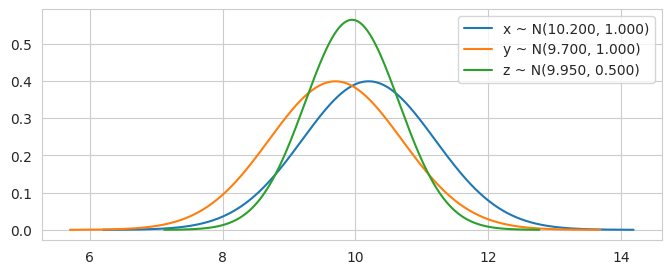

In [10]:
x = time_ut.Gaussian(10.2, 1)
y = time_ut.Gaussian(9.7, 1)

z = time_ut.gaussian_multiply(x, y)
print(z)

ax = time_ut.plot_gaussian(x, label="x")
time_ut.plot_gaussian(y, ax=ax, label="y")
time_ut.plot_gaussian(z, ax=ax, label="z");

**Goal**:
- Explore the product of two Gaussian PDFs $X \sim N(\mu_1, \sigma_1^2)$ and
  $Y \sim N(\mu_2, \sigma_2^2)$
- Observe how combining two beliefs (product) reduces uncertainty

**Plots**:
- Input Gaussians $X$ (blue) and $Y$ (yellow) as filled PDFs
- Analytical product $Z$ (red line)
- Numerical product via importance sampling (light coral histogram)

**Parameters**:
- `mu1` ($\mu_1$): mean of $X$
- `sigma1` ($\sigma_1$): standard deviation of $X$
- `mu2` ($\mu_2$): mean of $Y$
- `sigma2` ($\sigma_2$): standard deviation of $Y$

**Key observations**:
- The product pulls the mean toward the more certain (narrower) Gaussian
- The resulting variance is smaller than both input variances
- When inputs agree, the result is very sharp (high certainty)

In [11]:
# Interactive exploration of product of Gaussians.
time_ut.cell1_2_plot_gaussian_product()